In [23]:
MODEL      = "/Users/hamletkhachatryan/Desktop/DPhil_projects/pseudo/pandda_test/data/7h2x.pdb"
MODEL_mult = "/Users/hamletkhachatryan/Desktop/DPhil_projects/pseudo/pandda_test/7h2x_alt_conf.pdb"
MAP_ED     = "/Users/hamletkhachatryan/Desktop/DPhil_projects/pseudo/pandda_test/data/7h2x_refined.ccp4"    # electron density
MAP_SNR    = "/Users/hamletkhachatryan/Desktop/DPhil_projects/pseudo/pandda_test/quantify_results/k_1.0_cap_100/7h2x_snr.ccp4"      # SNR map
MAP_PVAL   = "/Users/hamletkhachatryan/Desktop/DPhil_projects/pseudo/pandda_test/quantify_results/k_1.0_cap_100/7h2x_p_value.ccp4"   # p-value map
RESOLUTION = 1.25
CHAIN      = "B"
LIG_SEQ_ID = 201                      
LIG_CHAIN  = "MB"
WATER_THRESHOLD = 0.4
OUT_DIR    = "Users/hamletkhachatryan/Desktop/DPhil_projects/pseudo/pandda_test"


In [2]:
from muse.visualization import (
    plot_residue_profile, extract_residue_scores, extract_bfactors,
    electron_density_config, snr_map_config, pvalue_map_config,plot_water_support
)
from muse import run_muse

result_ed  = run_muse(MAP_ED,   MODEL, RESOLUTION, config=electron_density_config())
result_snr = run_muse(MAP_SNR,  MODEL, RESOLUTION, config=snr_map_config(zeta=5.0))
result_pv  = run_muse(MAP_PVAL, MODEL, RESOLUTION, config=pvalue_map_config())


In [3]:

from muse.visualization import write_scored_pdb, plot_ligand_density_support

write_scored_pdb(result_ed, MODEL, f"{OUT_DIR}/model_ed_residue.pdb",
                 score_level="residue", score_field="musem", score_scale=100.0)

write_scored_pdb(result_ed, MODEL, f"{OUT_DIR}/model_ed_atom.pdb",
                 score_level="atom", score_field="score_positive", score_scale=100.0)

write_scored_pdb(result_snr, MODEL, f"{OUT_DIR}/model_snr_atom.pdb",
                 score_level="atom", score_field="score_positive", score_scale=100.0)

write_scored_pdb(result_pv, MODEL, f"{OUT_DIR}/model_pval_residue.pdb",
                 score_level="residue", score_field="musem", score_scale=100.0)


<gemmi.Atom N at (22.0, 6.4, 7.7)>
<gemmi.Atom N at (22.0, 6.4, 7.7)>
<gemmi.Atom N at (22.0, 6.4, 7.7)>
<gemmi.Atom N at (22.0, 6.4, 7.7)>


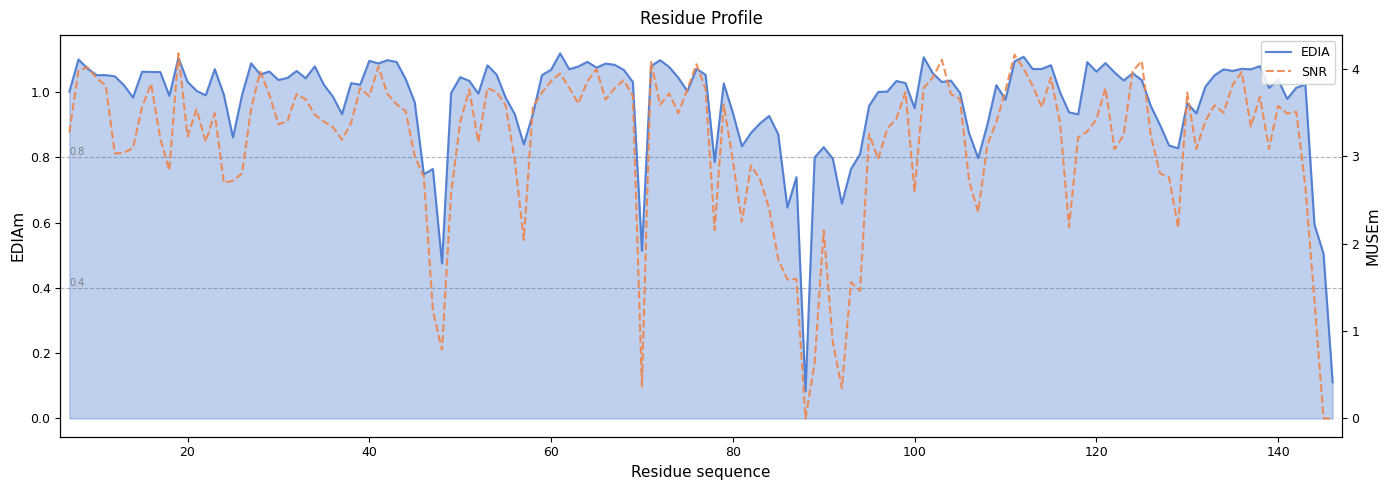

In [36]:
fig = plot_residue_profile(
    datasets={
        "EDIA"    : extract_residue_scores(result_ed,  chain_id=CHAIN),
        "SNR"     : extract_residue_scores(result_snr, chain_id=CHAIN),
        "p-value" : extract_residue_scores(result_pv,  chain_id=CHAIN),
    },
    left_series      = ["EDIA"],
    right_series     = ["SNR"],
    #bin_color_series = "p-value",      # background coloured by p-value MUSEm
    #bin_colormap     = "RdYlGn",
    #transforms       = {"SNR": ("log1p", 1.0)},   # compress high SNR values
    left_ylabel      = "EDIAm",
    right_ylabel     = "MUSEm",
    edia_threshold_lines = True,       # dashed lines at 0.4 and 0.8
    seq_range = (7,146)
)
fig.savefig(f"{OUT_DIR}/residue_profile.png", dpi=150, bbox_inches="tight")


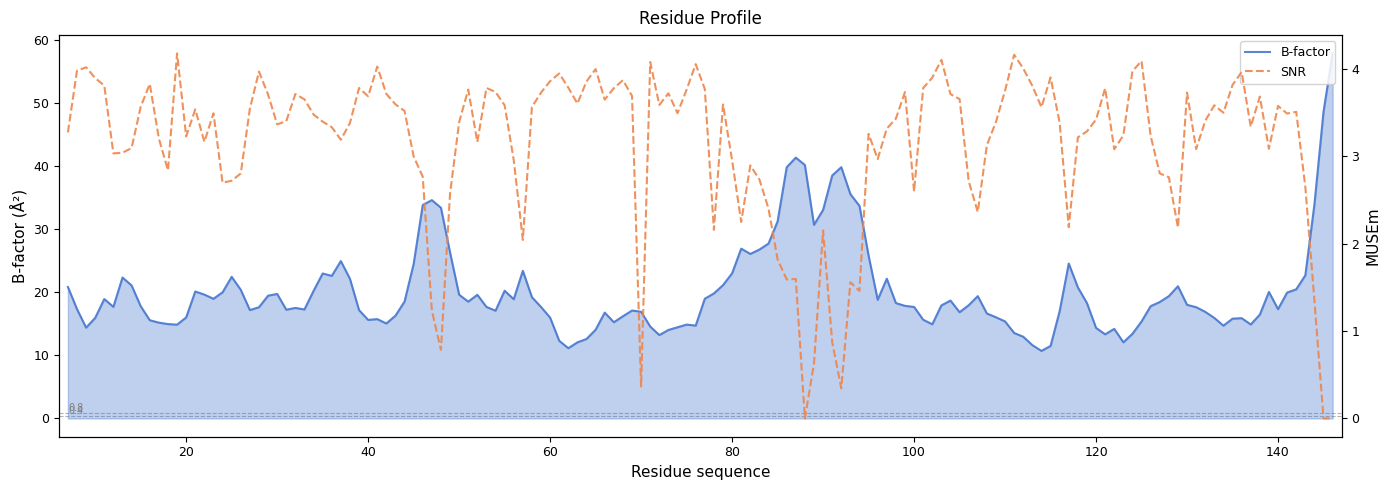

In [37]:
fig = plot_residue_profile(
    datasets={
        "B-factor": extract_bfactors(MODEL,            chain_id=CHAIN),
        "SNR"     : extract_residue_scores(result_snr, chain_id=CHAIN),
        "p-value" : extract_residue_scores(result_pv,  chain_id=CHAIN),
    },
    left_series      = ["B-factor"],
    right_series     = ["SNR"],
    #bin_color_series = "p-value",      # background coloured by p-value MUSEm
    bin_colormap     = "RdYlGn",
    #transforms       = {"SNR": ("log1p", 1.0)},   # compress high SNR values
    left_ylabel      = "B-factor (Å²)",
    right_ylabel     = "MUSEm",
    edia_threshold_lines = True,       # dashed lines at 0.4 and 0.8
    seq_range = (7,146)

)
fig.savefig(f"{OUT_DIR}/residue_profile.png", dpi=150, bbox_inches="tight")


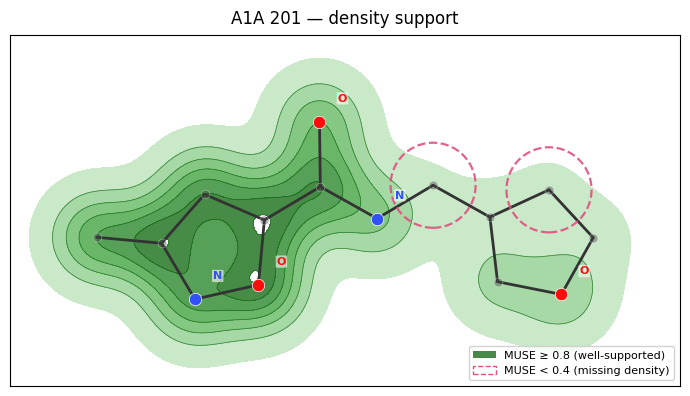

In [34]:
### From MUSE result
lig_scores = [a for a in result_snr.atom_scores
              if a.chain_id == LIG_CHAIN and a.residue_seq_id == LIG_SEQ_ID]

fig = plot_ligand_density_support(
    atom_scores=lig_scores, structure_path=MODEL,
    chain_id="MB", residue_seq_id=201,
    score_key="score_positive", projection="pca", bg_color = "white"
)



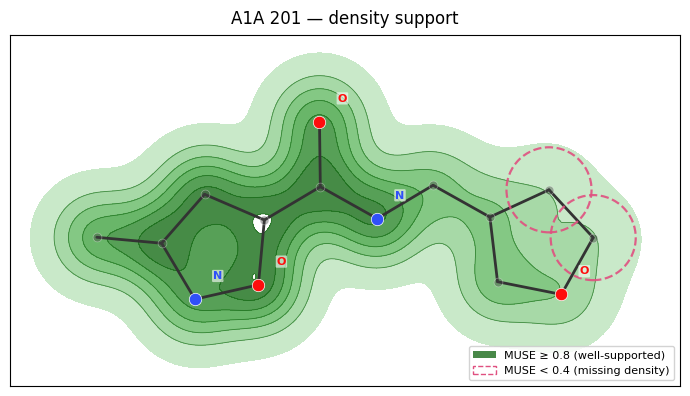

In [33]:
### From MUSE result
lig_scores = [a for a in result_ed.atom_scores
              if a.chain_id == LIG_CHAIN and a.residue_seq_id == LIG_SEQ_ID]

fig = plot_ligand_density_support(
    atom_scores=lig_scores, structure_path=MODEL,
    chain_id="B", residue_seq_id=89,
    score_key="score_positive", projection="pca", bg_color = "white", 
)


In [24]:
result_snr_multistate =  run_muse(MAP_SNR,  MODEL_mult, RESOLUTION, config=snr_map_config(zeta=5.0))

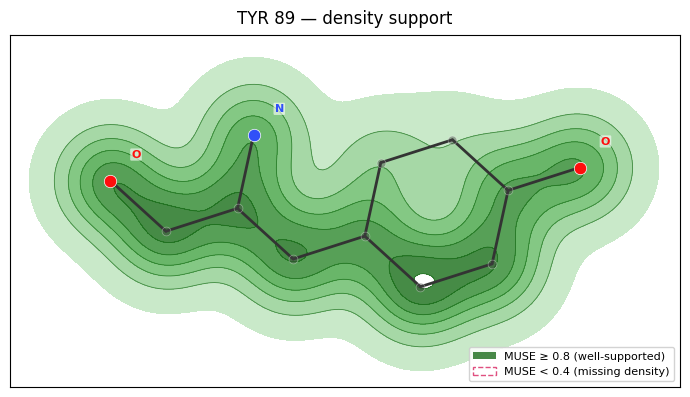

In [38]:
### From MUSE result
lig_scores = [a for a in result_snr_multistate.atom_scores
              if a.chain_id == "B" and a.residue_seq_id == 89]

fig = plot_ligand_density_support(
    atom_scores=lig_scores, structure_path=MODEL,
    chain_id="B", residue_seq_id=89,
    score_key="score_positive", projection="pca", bg_color = "white"
)


In [11]:
help(plot_ligand_density_support)

Help on function plot_ligand_density_support in module muse.visualization:

plot_ligand_density_support(atom_scores: 'Union[List[AtomScore], Dict[str, float]]', structure_path: 'str', chain_id: 'str', residue_seq_id: 'int', residue_name: 'Optional[str]' = None, insertion_code: 'str' = '', score_key: 'str' = 'score_positive', projection: 'str' = 'pca', grid_resolution: 'float' = 0.08, atom_sigma: 'float' = 0.7, n_contour_levels: 'int' = 6, good_threshold: 'float' = 0.8, poor_threshold: 'float' = 0.4, padding: 'float' = 2.0, figsize: 'Tuple[float, float]' = (7, 7), title: 'Optional[str]' = None, bg_color: 'str' = '#ebebeb', good_color: 'str' = '#1a6b1a', poor_color: 'str' = '#e05080', bond_color: 'str' = '#333333', bond_linewidth: 'float' = 2.0, show_atom_labels: 'bool' = True, label_carbon: 'bool' = False) -> 'Figure'
    Overlay per-atom density support on a 2-D projected small-molecule structure

    Args:
        atom_scores: Per-atom scores for the target residue.  Either:

        

Kept 2, removed 390 waters


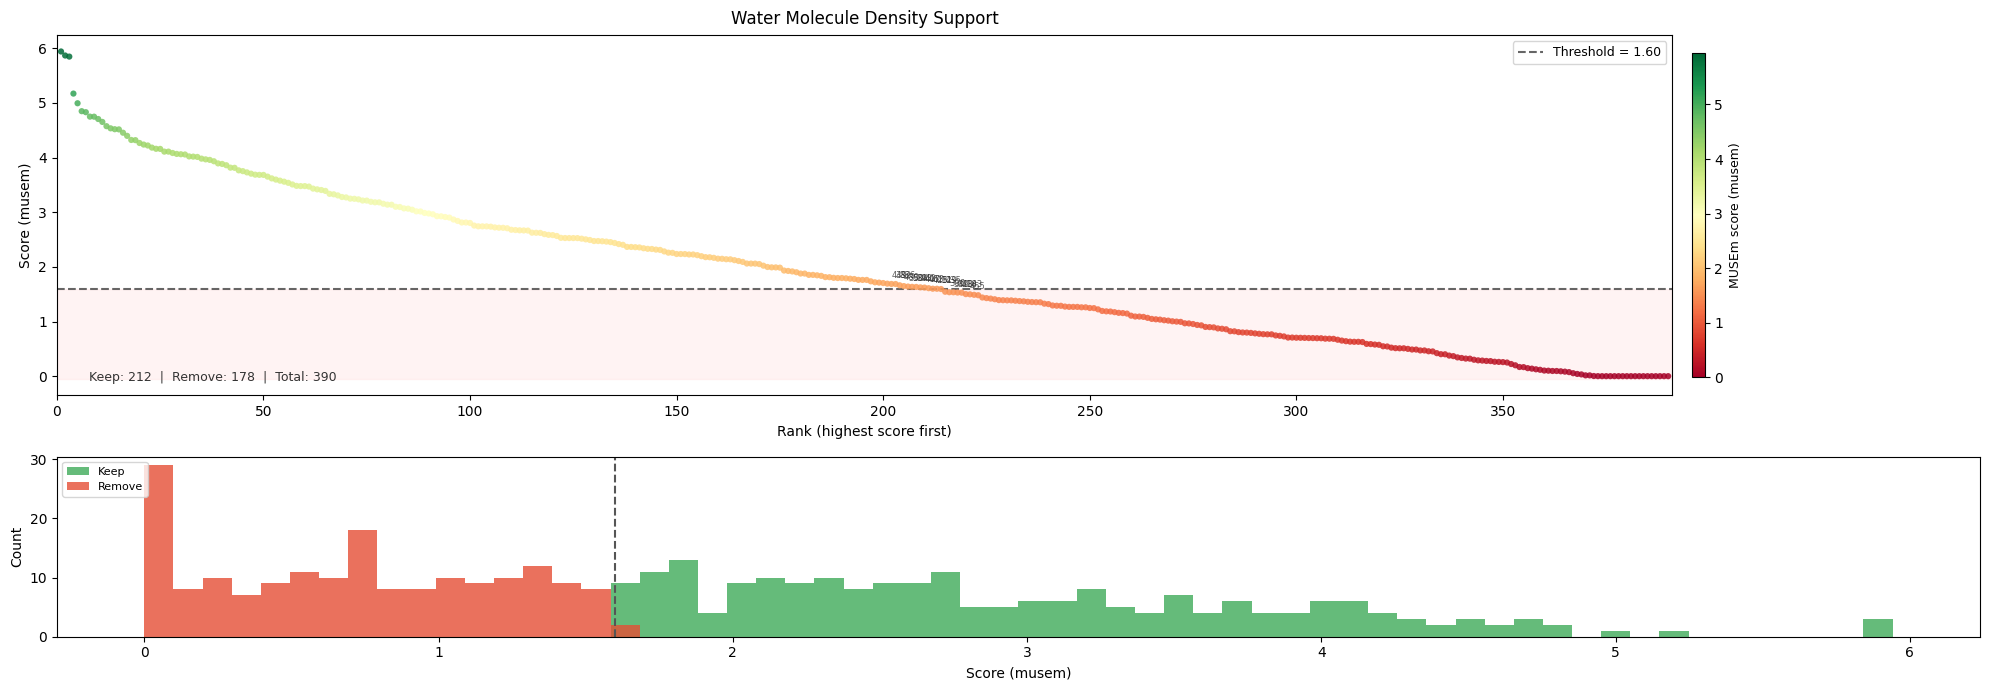

In [8]:
from  muse.visualization import filter_waters_by_score
# Visualise all waters
fig = plot_water_support(result_snr, threshold=1.6, colormap="RdYlGn")

# Write filtered PDB
n_kept, n_removed = filter_waters_by_score(
    result_pv, MODEL, f"{OUT_DIR}/model_filtered.pdb", threshold=1.6
)
print(f"Kept {n_kept}, removed {n_removed} waters")
